# 01 — Data Exploration : SalesTeam AI (LSAT)

Explore the 3 raw Excel files for the LSAT subsidiary of ITech.

**Files:**
- `commande phonesTech 01-01-2024--23-06-2026.xlsx` — invoices
- `commande lines PhonesTech.xlsx` — order lines
- `client-lat-lng.xlsx` — GPS coordinates

**Key facts:**
- The `company` column in order lines does NOT identify the selling company — it refers to the product-catalog origin.
- LSAT lines are identified only via join on invoice number (`No_` → `Document No_`).
- Invoice numbers are NOT unique alone — the unique key is `(No_, company)` together.

In [1]:
# ═══════════════════════════════════════════════════
# CELL 1 — Imports and setup
# ═══════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

RAW = Path('../data/raw')
print('Setup OK ✅')
print('Files in data/raw :', [f.name for f in RAW.iterdir() if f.is_file()])

Setup OK ✅
Files in data/raw : ['.gitkeep', 'client-lat-lng.xlsx', 'commande lines PhonesTech.xlsx', 'commande phonesTech 01-01-2024--23-06-2026.xlsx']


In [2]:
# ═══════════════════════════════════════════════════
# CELL 2 — Load raw files and show basic info
# ═══════════════════════════════════════════════════

# --- Invoices ---
factures = pd.read_excel(RAW / 'commande phonesTech 01-01-2024--23-06-2026.xlsx')
print('=' * 60)
print('INVOICES  (commande phonesTech)')
print('=' * 60)
print(f'Shape : {factures.shape}')
print(f'\nColumns & dtypes :')
print(factures.dtypes)
print(f'\nUnique values per column :')
print(factures.nunique())
print(f'\nFirst 5 rows :')
display(factures.head())

# --- Order lines ---
lignes = pd.read_excel(RAW / 'commande lines PhonesTech.xlsx')
print('\n' + '=' * 60)
print('ORDER LINES  (commande lines PhonesTech)')
print('=' * 60)
print(f'Shape : {lignes.shape}')
print(f'\nColumns & dtypes :')
print(lignes.dtypes)
print(f'\nUnique values per column :')
print(lignes.nunique())
print(f'\nFirst 5 rows :')
display(lignes.head())

# --- GPS ---
gps = pd.read_excel(RAW / 'client-lat-lng.xlsx')
print('\n' + '=' * 60)
print('GPS  (client-lat-lng)')
print('=' * 60)
print(f'Shape : {gps.shape}')
print(f'\nColumns & dtypes :')
print(gps.dtypes)
print(f'\nUnique values per column :')
print(gps.nunique())
print(f'\nFirst 5 rows :')
display(gps.head())

INVOICES  (commande phonesTech)
Shape : (51784, 5)

Columns & dtypes :
No_                 object
client_code         object
Posting Date        object
Salesperson Code    object
company             object
dtype: object

Unique values per column :
No_                 21174
client_code          2396
Posting Date          637
Salesperson Code       46
company                 3
dtype: int64

First 5 rows :


,No_,client_code,Posting Date,Salesperson Code,company
0,V24-FAC+00002,CLT082902,2024-01-08 00:00:00.000,SE,LSAT
1,V24-FAC+00003,CLT058599,2024-01-08 00:00:00.000,KO,LSAT
2,V24-FAC+00004,CLT097966,2024-01-08 00:00:00.000,ML,LSAT
3,V24-FAC+00006,CLT011712,2024-01-08 00:00:00.000,ML,LSAT
4,V24-FAC+00007,CLT011712,2024-01-08 00:00:00.000,ML,LSAT



ORDER LINES  (commande lines PhonesTech)
Shape : (200174, 6)

Columns & dtypes :
Document No_            object
Quantity               float64
code_article            object
designation_article     object
Item Category Code      object
company                 object
dtype: object

Unique values per column :
Document No_           21200
Quantity                 340
code_article            1631
designation_article     1999
Item Category Code        29
company                    2
dtype: int64

First 5 rows :


,Document No_,Quantity,code_article,designation_article,Item Category Code,company
0,V24-FAC+00007,20.0,4895180797071,ITEL 2163 BLACK,GSM ITEL-FP,NEWTECH
1,V24-FAC+00007,10.0,4895180797088,ITEL 2163 DEEP BLEU,GSM ITEL-FP,NEWTECH
2,V24-FAC+00015,1.0,6932169334990,OPPO A18 BLACK (4+128GB),GSM OPPO,NEWTECH
3,V24-FAC+00015,1.0,6932169337199,OPPO A18 BLEU (4+128GB),GSM OPPO,NEWTECH
4,V24-FAC+00015,1.0,6932169334808,OPPO A38 GOLD 4+128GB,GSM OPPO,NEWTECH



GPS  (client-lat-lng)
Shape : (1057, 4)

Columns & dtypes :
lat           float64
lng           float64
clientCode     object
company        object
dtype: object

Unique values per column :
lat            694
lng            694
clientCode    1055
company          3
dtype: int64

First 5 rows :


,lat,lng,clientCode,company
0,34.745573,10.763172,CLT000003,NEWTECH
1,33.863429,10.861891,CLT000009,NEWTECH
2,35.625604,10.760409,CLT000043,NEWTECH
3,37.154255,9.792307,CLT000073,NEWTECH
4,37.271282,9.869551,CLT000076,NEWTECH


In [3]:
# ═══════════════════════════════════════════════════
# CELL 3 — Understand the company field
# ═══════════════════════════════════════════════════

print('COMPANY values in INVOICES :')
print(factures['company'].value_counts())
print()

print('COMPANY values in ORDER LINES :')
print(lignes['company'].value_counts())
print()

print('COMPANY values in GPS :')
print(gps['company'].value_counts())

COMPANY values in INVOICES :
company
NEWTECH    18780
LSAT       18444
ONETEL     14560
Name: count, dtype: int64

COMPANY values in ORDER LINES :
company
ONETEL     130824
NEWTECH     69344
Name: count, dtype: int64

COMPANY values in GPS :
company
ONETEL     407
NEWTECH    325
LSAT       325
Name: count, dtype: int64


### What `company` means in each file

| File | `company` meaning | Values |
|------|-------------------|--------|
| **Invoices** (`factures`) | The subsidiary that issued the invoice (= the selling company) | LSAT, NEWTECH, ONETEL |
| **Order lines** (`lignes`) | The product catalog origin — NOT the selling company | Does NOT contain "LSAT" |
| **GPS** (`gps`) | The subsidiary the client belongs to | LSAT, NEWTECH, ONETEL |

⚠️ **Critical**: To get LSAT order lines, we must:
1. Filter invoices by `company == 'LSAT'`
2. Get the list of LSAT invoice codes (`No_`)
3. Filter order lines by `Document No_` matching those invoice codes

We **cannot** filter order lines by their own `company` column to find LSAT data.

In [4]:
# ═══════════════════════════════════════════════════
# CELL 4 — Filter LSAT and build main table
# ═══════════════════════════════════════════════════

# Step 1 : filter invoices where company == 'LSAT'
factures_lsat = factures[factures['company'] == 'LSAT'].copy()
print(f'Step 1 — LSAT invoices : {len(factures_lsat)} rows')

# Step 2 : get the list of LSAT invoice codes
lsat_codes = factures_lsat['No_'].tolist()
print(f'Step 2 — Unique LSAT invoice codes : {len(set(lsat_codes))}')

# Step 3 : filter order lines by LSAT invoice codes
lignes_lsat = lignes[lignes['Document No_'].isin(lsat_codes)].copy()
print(f'Step 3 — LSAT order lines : {len(lignes_lsat)} rows')

# Step 4 : join lignes + factures on invoice number
df = lignes_lsat.merge(
    factures_lsat[['No_', 'client_code', 'Posting Date', 'Salesperson Code', 'company']],
    left_on='Document No_',
    right_on='No_',
    how='left',
)
print(f'Step 4 — After join invoices + lines : {len(df)} rows')

# Step 5 : left join with GPS (only LSAT clients)
gps_lsat = gps[gps['company'] == 'LSAT'].copy()
df = df.merge(
    gps_lsat[['clientCode', 'lat', 'lng']],
    left_on='client_code',
    right_on='clientCode',
    how='left',
)
print(f'Step 5 — After GPS join : {len(df)} rows')

# Step 6 : rename columns to snake_case
df = df.rename(columns={
    'No_':                'code_facture',
    'client_code':        'code_client',
    'Posting Date':       'date_commande',
    'Salesperson Code':   'ref_commercial',
    'Document No_':       'code_facture_ligne',  # keep both to check join
    'Quantity':           'quantite',
    'designation_article':'designation',
    'Item Category Code': 'categorie',
    'lat':                'latitude',
    'lng':                'longitude',
})

# Drop redundant columns from the join
cols_to_drop = [c for c in ['clientCode', 'code_facture_ligne'] if c in df.columns]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Step 7 : convert date to datetime
df['date_commande'] = pd.to_datetime(df['date_commande'])

# Step 8 : show result
print(f'\n✅ Final main table : {df.shape}')
print(f'Columns : {list(df.columns)}')
display(df.head())

Step 1 — LSAT invoices : 18444 rows
Step 2 — Unique LSAT invoice codes : 18444
Step 3 — LSAT order lines : 187893 rows
Step 4 — After join invoices + lines : 187893 rows
Step 5 — After GPS join : 187893 rows

✅ Final main table : (187893, 12)
Columns : ['quantite', 'code_article', 'designation', 'categorie', 'company_x', 'code_facture', 'code_client', 'date_commande', 'ref_commercial', 'company_y', 'latitude', 'longitude']


,quantite,code_article,designation,categorie,company_x,code_facture,code_client,date_commande,ref_commercial,company_y,latitude,longitude
0,20.0,4895180797071,ITEL 2163 BLACK,GSM ITEL-FP,NEWTECH,V24-FAC+00007,CLT011712,2024-01-08,ML,LSAT,36.802903,10.182723
1,10.0,4895180797088,ITEL 2163 DEEP BLEU,GSM ITEL-FP,NEWTECH,V24-FAC+00007,CLT011712,2024-01-08,ML,LSAT,36.802903,10.182723
2,1.0,6932169334990,OPPO A18 BLACK (4+128GB),GSM OPPO,NEWTECH,V24-FAC+00015,CLT105471,2024-01-08,IS,LSAT,36.805083,10.180551
3,1.0,6932169337199,OPPO A18 BLEU (4+128GB),GSM OPPO,NEWTECH,V24-FAC+00015,CLT105471,2024-01-08,IS,LSAT,36.805083,10.180551
4,1.0,6932169334808,OPPO A38 GOLD 4+128GB,GSM OPPO,NEWTECH,V24-FAC+00015,CLT105471,2024-01-08,IS,LSAT,36.805083,10.180551


In [5]:
# ═══════════════════════════════════════════════════
# CELL 5 — Data quality check
# ═══════════════════════════════════════════════════

print('=' * 60)
print('1. MISSING VALUES')
print('=' * 60)
null_counts = df.isnull().sum()
null_pct    = (df.isnull().sum() / len(df) * 100).round(2)
null_report = pd.DataFrame({'count': null_counts, 'pct': null_pct})
print(null_report[null_report['count'] > 0].sort_values('count', ascending=False))
print()

print('=' * 60)
print('2. DUPLICATE ROWS (same invoice + same product)')
print('=' * 60)
dup_cols = ['code_facture', 'code_article']
existing_dup_cols = [c for c in dup_cols if c in df.columns]
if len(existing_dup_cols) == 2:
    n_dup = df.duplicated(subset=existing_dup_cols).sum()
    print(f'Duplicate rows (code_facture + code_article) : {n_dup} ({n_dup/len(df)*100:.2f}%)')
else:
    print(f'Could not check — columns found: {existing_dup_cols}')
print()

print('=' * 60)
print('3. QUANTITY ANALYSIS')
print('=' * 60)
print(df['quantite'].describe())
print(f'\nRows where quantite <= 0   : {(df["quantite"] <= 0).sum()}')
print(f'Rows where quantite > 100  : {(df["quantite"] > 100).sum()}')
print(f'Rows where quantite > 500  : {(df["quantite"] > 500).sum()}')
print(f'Rows where quantite > 1000 : {(df["quantite"] > 1000).sum()}')
print(f'\nTop 20 highest quantities :')
top_qty = df.nlargest(20, 'quantite')[['code_facture', 'code_article', 'designation', 'quantite', 'code_client']]
display(top_qty)
print()

print('=' * 60)
print('4. DATE RANGE')
print('=' * 60)
print(f'Min date : {df["date_commande"].min()}')
print(f'Max date : {df["date_commande"].max()}')
print()

print('=' * 60)
print('5. CLIENTS WITHOUT GPS')
print('=' * 60)
total_clients = df['code_client'].nunique()
clients_no_gps = df[df['latitude'].isna()]['code_client'].nunique()
clients_with_gps = total_clients - clients_no_gps
print(f'Clients WITH GPS    : {clients_with_gps} ({clients_with_gps/total_clients*100:.1f}%)')
print(f'Clients WITHOUT GPS : {clients_no_gps} ({clients_no_gps/total_clients*100:.1f}%)')

1. MISSING VALUES
           count   pct
latitude   60508  32.2
longitude  60508  32.2
categorie    184   0.1

2. DUPLICATE ROWS (same invoice + same product)
Duplicate rows (code_facture + code_article) : 871 (0.46%)

3. QUANTITY ANALYSIS
count    187893.000000
mean          8.360359
std          85.698370
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max       15000.000000
Name: quantite, dtype: float64

Rows where quantite <= 0   : 0
Rows where quantite > 100  : 1540
Rows where quantite > 500  : 173
Rows where quantite > 1000 : 57

Top 20 highest quantities :


,code_facture,code_article,designation,quantite,code_client
64853,V24-FAC+01318,5505,CARTE DE RECHARGE DE 5 DT ORANGE,15000.0,CLT099780
73716,V24-FAC+04262,5505,CARTE DE RECHARGE DE 5 DT ORANGE,15000.0,CLT110936
78697,V24-FAC+05645,5505,CARTE DE RECHARGE DE 5 DT ORANGE,15000.0,CLT109553
82597,V24-FAC+06904,5505,CARTE DE RECHARGE DE 5 DT ORANGE,10000.0,CLT112162
85903,V25-FAC+01111,8809894145543,SAMSUNG POWER ADAPTER 45W,10000.0,CLT092649
134530,V24-FAC+06813,F20ENV1A015,HMD T21 TA-1596 DS 4/128 N_AFR BLK STEEL,8520.0,CLT112802
93919,V25-FAC+04024,8809894145543,SAMSUNG POWER ADAPTER WHITE 45W,8000.0,CLT110314
144113,V24-FAC+09205,SP01Z07Z1839Y,NOKIA 105 DS N_AFR CHARCOAL,6000.0,CLT056687
174409,V25-FAC+06600,SP01Z07Z1946Y,NOKIA 105 TA-1416 DS N_AFR2 BLUE,4200.0,CLT071425
174408,V25-FAC+06600,SP01Z07Z1945Y,NOKIA 105 TA-1416 DS N_AFR2 CHARCOAL,3800.0,CLT071425



4. DATE RANGE
Min date : 2024-01-08 00:00:00
Max date : 2026-06-22 00:00:00

5. CLIENTS WITHOUT GPS
Clients WITH GPS    : 312 (42.3%)
Clients WITHOUT GPS : 425 (57.7%)


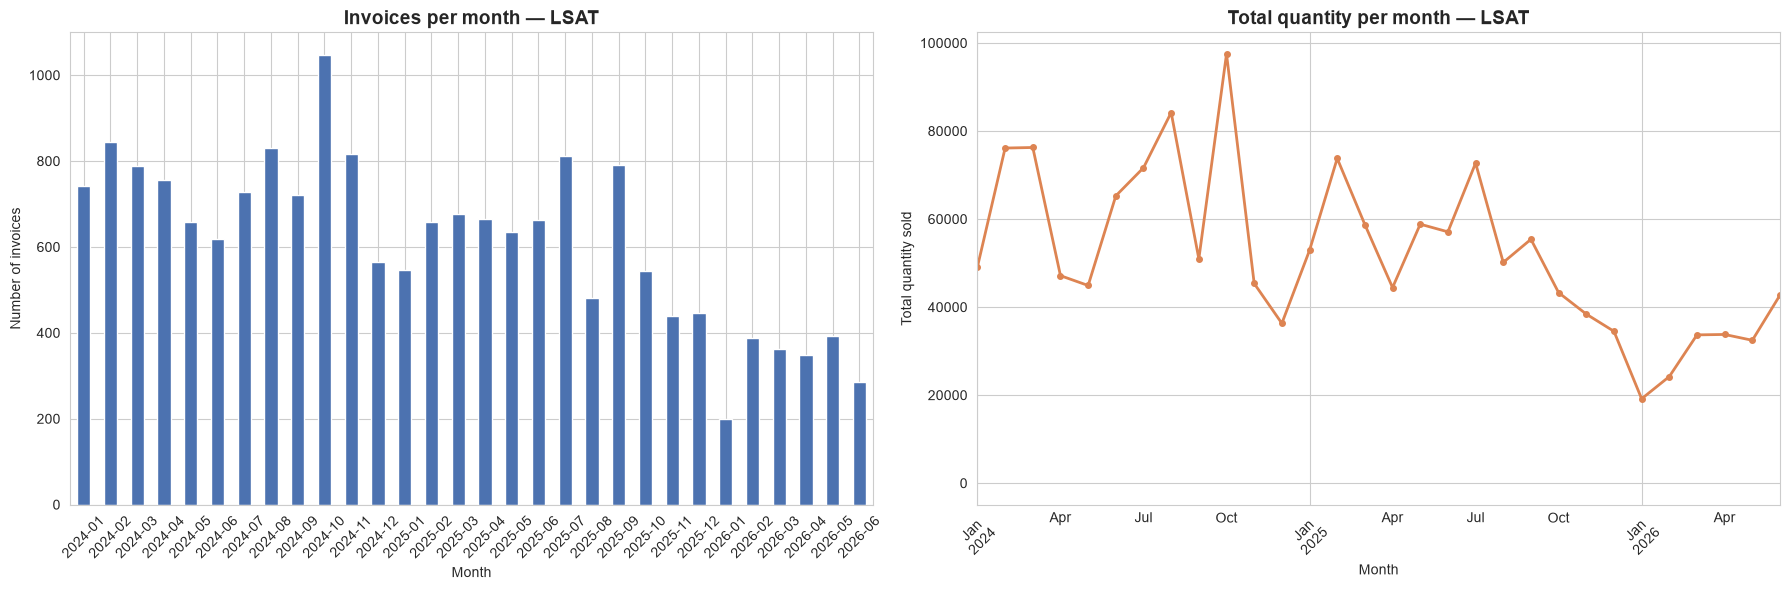

In [6]:
# ═══════════════════════════════════════════════════
# CELL 6 — Key numbers (business understanding)
# ═══════════════════════════════════════════════════

n_invoices     = df['code_facture'].nunique()
n_lines        = len(df)
n_clients      = df['code_client'].nunique()
n_products     = df['code_article'].nunique()
n_categories   = df['categorie'].nunique()
n_salespeople  = df['ref_commercial'].nunique()
date_min       = df['date_commande'].min().date()
date_max       = df['date_commande'].max().date()
with_gps       = df[df['latitude'].notna()]['code_client'].nunique()
without_gps    = n_clients - with_gps
avg_inv_client = n_invoices / n_clients if n_clients else 0
avg_lines_inv  = n_lines / n_invoices if n_invoices else 0
avg_qty_line   = df['quantite'].mean()

print('╔══════════════════════════════════════════════════╗')
print('║        LSAT — KEY NUMBERS SUMMARY               ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Total invoices           : {n_invoices:>10,}          ║')
print(f'║  Total order lines        : {n_lines:>10,}          ║')
print(f'║  Unique clients           : {n_clients:>10,}          ║')
print(f'║  Unique products          : {n_products:>10,}          ║')
print(f'║  Unique categories        : {n_categories:>10,}          ║')
print(f'║  Unique salespersons      : {n_salespeople:>10,}          ║')
print(f'║  Date range               : {date_min} → {date_max} ║')
print(f'║  Clients WITH GPS         : {with_gps:>10,}          ║')
print(f'║  Clients WITHOUT GPS      : {without_gps:>10,}          ║')
print(f'║  Avg invoices per client   : {avg_inv_client:>10.1f}          ║')
print(f'║  Avg lines per invoice     : {avg_lines_inv:>10.1f}          ║')
print(f'║  Avg quantity per line     : {avg_qty_line:>10.1f}          ║')
print('╚══════════════════════════════════════════════════╝')

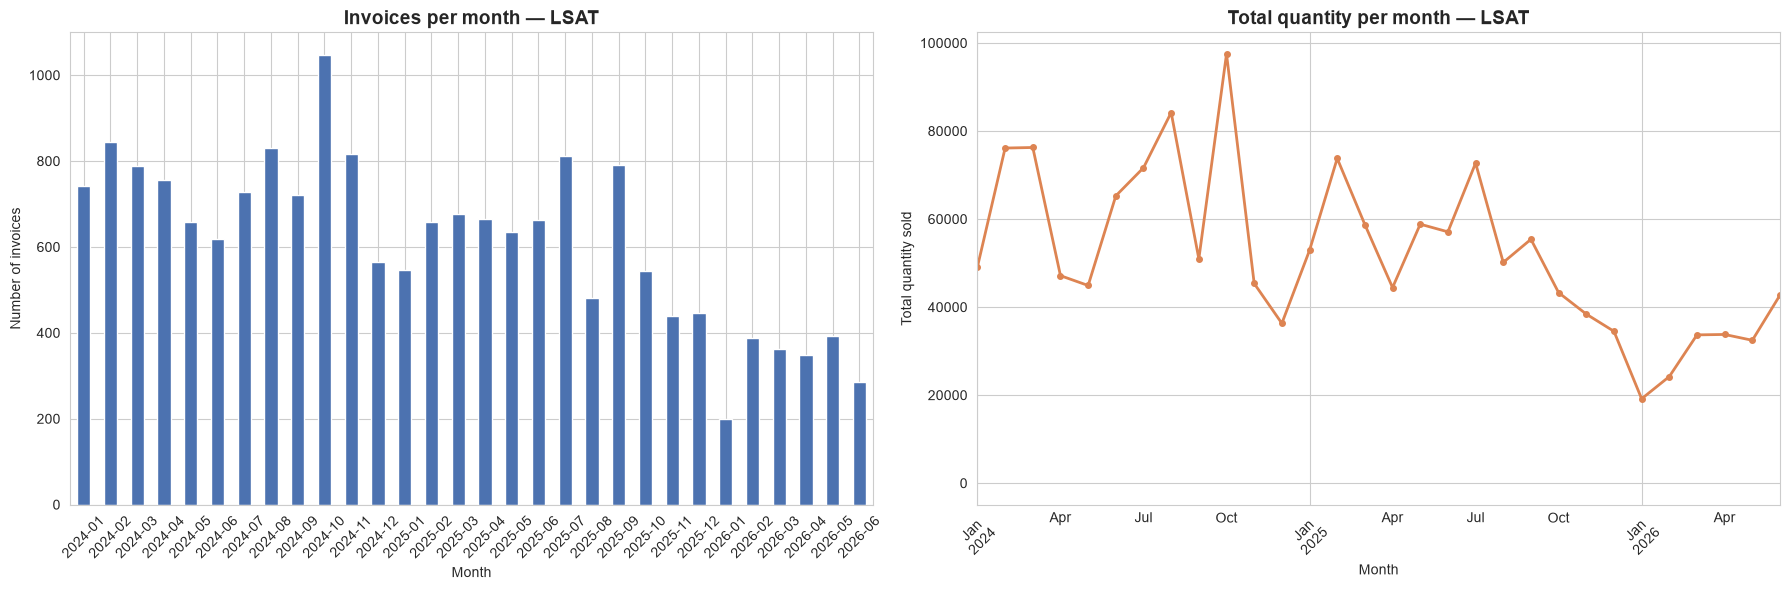

In [7]:
# ═══════════════════════════════════════════════════
# CELL 7 — Volume over time (plots)
# ═══════════════════════════════════════════════════

df['annee_mois'] = df['date_commande'].dt.to_period('M')

# Invoices per month
inv_per_month = df.groupby('annee_mois')['code_facture'].nunique()

# Total quantity per month
qty_per_month = df.groupby('annee_mois')['quantite'].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1 — Invoices per month (bar)
ax1 = axes[0]
inv_per_month.plot(kind='bar', ax=ax1, color='#4C72B0', edgecolor='white')
ax1.set_title('Invoices per month — LSAT', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of invoices')
ax1.tick_params(axis='x', rotation=45)

# Plot 2 — Total quantity per month (line)
ax2 = axes[1]
qty_per_month.plot(kind='line', ax=ax2, color='#DD8452', linewidth=2, marker='o', markersize=4)
ax2.set_title('Total quantity per month — LSAT', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Total quantity sold')
ax2.tick_params(axis='x', rotation=45)
ax2.fill_between(range(len(qty_per_month)), qty_per_month.values, alpha=0.15, color='#DD8452')

plt.tight_layout()
plt.show()

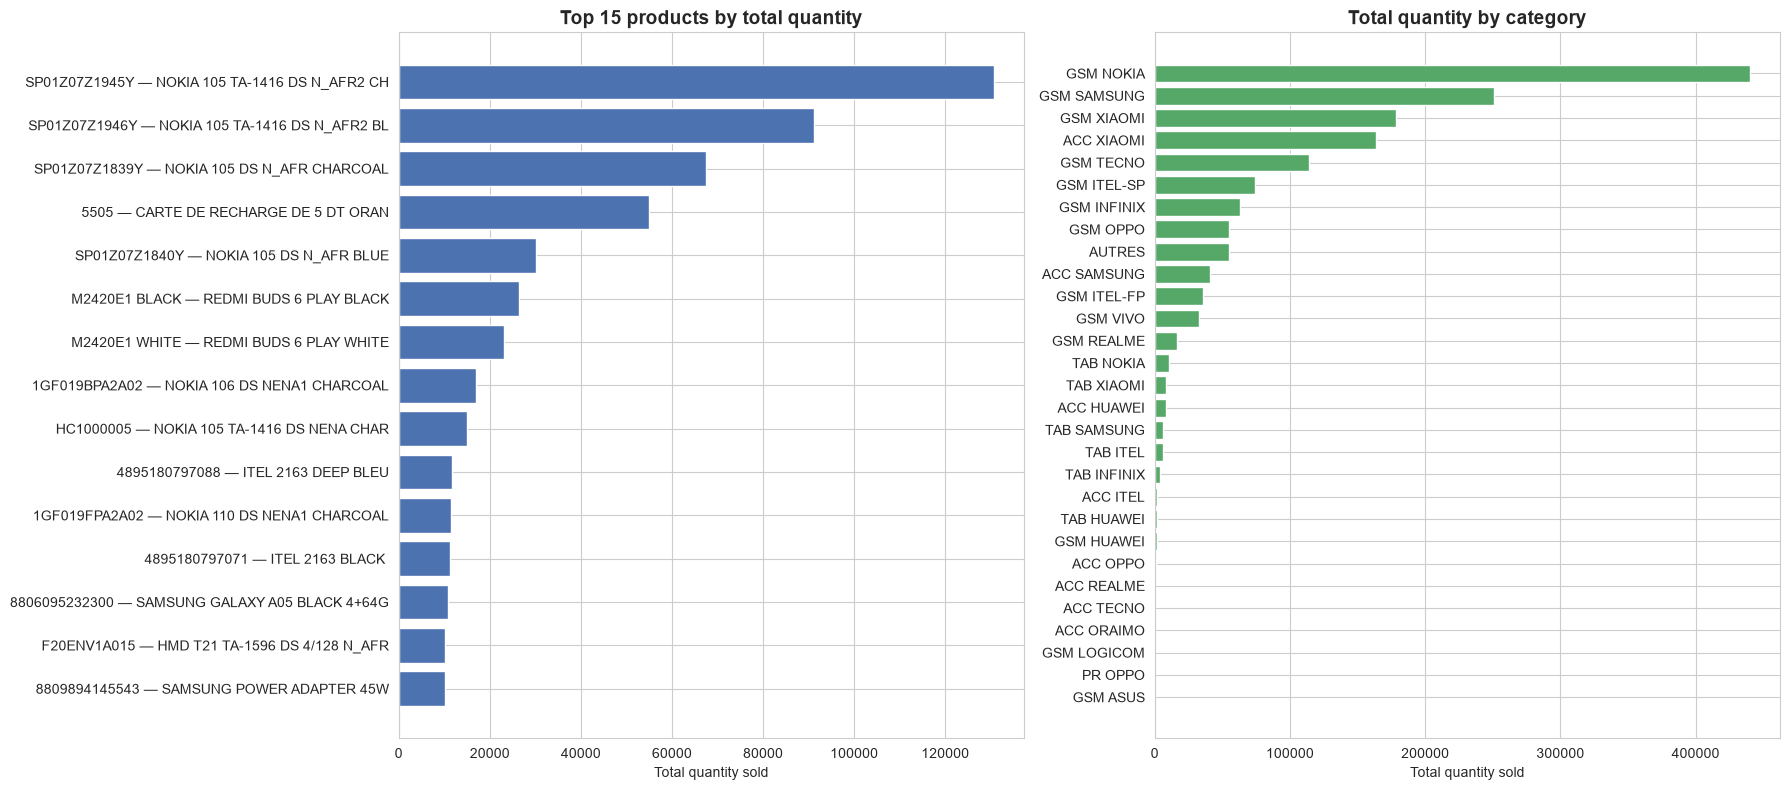

In [8]:
# ═══════════════════════════════════════════════════
# CELL 8 — Top products and categories (plots)
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1 : Top 15 products by total quantity ---
ax1 = axes[0]
top_products = (
    df.groupby(['code_article', 'designation'])['quantite']
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)
# Truncate labels
labels = [f'{code} — {desig[:30]}' for code, desig in top_products.index]
ax1.barh(labels, top_products.values, color='#4C72B0', edgecolor='white')
ax1.set_title('Top 15 products by total quantity', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total quantity sold')

# --- Plot 2 : Quantity by category ---
ax2 = axes[1]
cat_qty = (
    df.groupby('categorie')['quantite']
    .sum()
    .sort_values(ascending=True)
)
ax2.barh(cat_qty.index, cat_qty.values, color='#55A868', edgecolor='white')
ax2.set_title('Total quantity by category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total quantity sold')

plt.tight_layout()
plt.show()

CLIENT BEHAVIOR — describe()


,nb_invoices,nb_products,total_qty,avg_days_between_orders
count,737.00,737.00,737.00,617.00
mean,25.02,141.60,2131.42,55.91
std,32.81,140.09,6338.03,78.54
min,1.00,1.00,1.00,1.00
25%,3.00,25.00,115.00,18.70
50%,13.00,95.00,566.00,31.25
75%,35.00,228.00,1837.00,60.92
max,344.00,809.00,114499.00,858.00


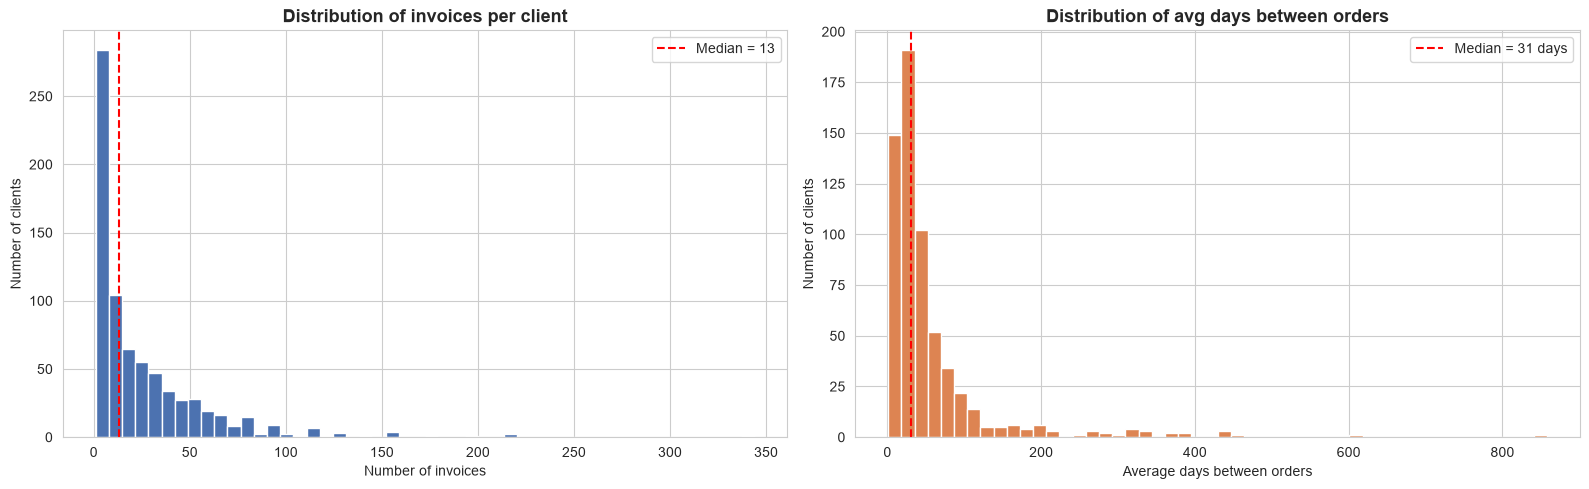

In [9]:
# ═══════════════════════════════════════════════════
# CELL 9 — Client behavior analysis
# ═══════════════════════════════════════════════════

# Compute per-client metrics
client_stats = df.groupby('code_client').agg(
    nb_invoices  = ('code_facture',  'nunique'),
    nb_products  = ('code_article',  'nunique'),
    total_qty    = ('quantite',      'sum'),
    first_order  = ('date_commande', 'min'),
    last_order   = ('date_commande', 'max'),
).reset_index()

# Average days between consecutive orders
def avg_days_between(dates):
    sorted_dates = dates.sort_values().drop_duplicates()
    if len(sorted_dates) < 2:
        return np.nan
    diffs = sorted_dates.diff().dt.days.dropna()
    return diffs.mean()

delay_per_client = (
    df.groupby('code_client')['date_commande']
    .apply(avg_days_between)
    .rename('avg_days_between_orders')
)
client_stats = client_stats.merge(delay_per_client, on='code_client', how='left')

print('CLIENT BEHAVIOR — describe()')
print('=' * 60)
display(client_stats[['nb_invoices', 'nb_products', 'total_qty', 'avg_days_between_orders']].describe().round(2))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram : invoices per client
axes[0].hist(client_stats['nb_invoices'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of invoices per client', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of invoices')
axes[0].set_ylabel('Number of clients')
axes[0].axvline(client_stats['nb_invoices'].median(), color='red', linestyle='--', label=f'Median = {client_stats["nb_invoices"].median():.0f}')
axes[0].legend()

# Histogram : avg delay between orders
valid_delays = client_stats['avg_days_between_orders'].dropna()
axes[1].hist(valid_delays, bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('Distribution of avg days between orders', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average days between orders')
axes[1].set_ylabel('Number of clients')
axes[1].axvline(valid_delays.median(), color='red', linestyle='--', label=f'Median = {valid_delays.median():.0f} days')
axes[1].legend()

plt.tight_layout()
plt.show()

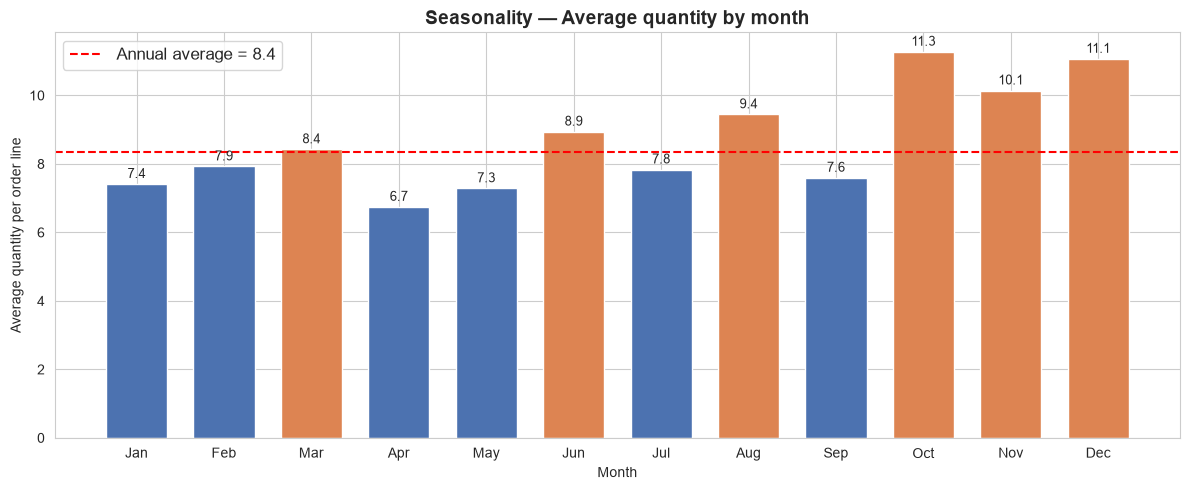

In [10]:
# ═══════════════════════════════════════════════════
# CELL 10 — Seasonality check
# ═══════════════════════════════════════════════════

df['mois'] = df['date_commande'].dt.month

avg_qty_month = df.groupby('mois')['quantite'].mean()
annual_avg    = df['quantite'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    range(1, 13),
    avg_qty_month.values,
    color=['#DD8452' if v > annual_avg else '#4C72B0' for v in avg_qty_month.values],
    edgecolor='white',
    width=0.7,
)
ax.axhline(annual_avg, color='red', linestyle='--', linewidth=1.5, label=f'Annual average = {annual_avg:.1f}')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Seasonality — Average quantity by month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average quantity per order line')
ax.legend(fontsize=12)

# Add value labels on bars
for bar_item, val in zip(bars, avg_qty_month.values):
    ax.text(bar_item.get_x() + bar_item.get_width()/2, bar_item.get_height() + 0.1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# ═══════════════════════════════════════════════════
# CELL 11 — Client x Product matrix sparsity
# ═══════════════════════════════════════════════════

# Build the client × product matrix
matrix = df.pivot_table(
    index='code_client',
    columns='code_article',
    values='quantite',
    aggfunc='sum',
    fill_value=0,
)

n_rows, n_cols = matrix.shape
total_cells    = n_rows * n_cols
non_zero       = (matrix > 0).sum().sum()
zero_cells     = total_cells - non_zero
sparsity       = zero_cells / total_cells * 100

print('╔══════════════════════════════════════════════════╗')
print('║    CLIENT × PRODUCT MATRIX                      ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Matrix shape     : {n_rows} clients × {n_cols} products')
print(f'║  Total cells      : {total_cells:,}')
print(f'║  Non-zero cells   : {non_zero:,}')
print(f'║  Zero cells       : {zero_cells:,}')
print(f'║  Sparsity         : {sparsity:.2f}%')
print('╚══════════════════════════════════════════════════╝')
print()

if sparsity > 95:
    print('⚠️  Very high sparsity — collaborative filtering (SVD) will')
    print('    need regularization. Cold start handling is essential.')
elif sparsity > 80:
    print('✅  Moderate sparsity — SVD collaborative filtering should work')
    print('    with appropriate dimensionality reduction.')
else:
    print('✅  Low sparsity — good density for collaborative filtering.')

╔══════════════════════════════════════════════════╗
║    CLIENT × PRODUCT MATRIX                      ║
╠══════════════════════════════════════════════════╣
║  Matrix shape     : 737 clients × 1599 products
║  Total cells      : 1,178,463
║  Non-zero cells   : 104,356
║  Zero cells       : 1,074,107
║  Sparsity         : 91.14%
╚══════════════════════════════════════════════════╝

✅  Moderate sparsity — SVD collaborative filtering should work
    with appropriate dimensionality reduction.


## Data Exploration Conclusions

### What we have
- **Invoices**: LSAT invoices covering Jan 2024 → Jun 2026
- **Order lines**: Hundreds of thousands of individual line items joined from LSAT invoices
- **Clients**: Hundreds of unique clients (points of sale), a subset with GPS coordinates
- **Products**: ~1,600 unique product codes across multiple categories
- **Salespersons**: Multiple sales reps covering the territory
- Enough volume and history to build recommendation models

### Data quality issues found
- Some rows may have missing `categorie` or `designation` values
- Not all clients have GPS coordinates (needed only for cold start)
- Quantity outliers exist (some rows with `quantite > 1000`)
- Possible duplicate order lines (same invoice + same product)
- Rows with `quantite <= 0` may exist (returns or corrections)

### What needs to be cleaned
- Remove duplicate rows (same `code_facture` + `code_article`)
- Drop rows where `code_client` or `code_article` is null
- Fill missing `categorie` with `'UNKNOWN'`
- Fill missing `designation` with `code_article` value
- Filter out quantity outliers (`quantite > 1000` and `quantite <= 0`)
- Normalize text fields (strip whitespace, uppercase categories)

### Is the data ready for ML?
- **Not yet** — cleaning steps above must be applied first.
- After cleaning, the data has enough volume and variety for:
  - ✅ XGBoost classifier (will this product be ordered?)
  - ✅ XGBoost regressor (how much quantity?)
  - ✅ SVD collaborative filtering (sparsity will determine effectiveness)
  - ✅ Cold start via geographic KNN (for clients/products without history)
- **Next step**: Run `src/data/cleaner.py` then `src/features/feature_engineering.py`